In [77]:
import pandas as pd
import snowflake.connector

conn = snowflake.connector.connect(
    user='HARINI',
    password='Ice2006@@harini',
    account='SNPZCQJ-DH96439',
    database='WATER',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

query = 'SELECT * FROM WATER_PORTABLE'

df = pd.read_sql(query, conn)

print(df.head())

conn.close()

C:\Users\harin\AppData\Local\Temp\ipykernel_21024\4147797242.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [78]:
df.shape

(3276, 10)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [80]:
df.isna().sum()

PH                 491
HARDNESS             0
SOLIDS               0
CHLORAMINES          0
SULFATE            781
CONDUCTIVITY         0
ORGANIC_CARBON       0
TRIHALOMETHANES    162
TURBIDITY            0
POTABILITY           0
dtype: int64

In [81]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [82]:
from sklearn.impute import SimpleImputer
sm=SimpleImputer(strategy='mean')
df[['PH','SULFATE','TRIHALOMETHANES']]=sm.fit_transform(df[['PH','SULFATE','TRIHALOMETHANES']])

In [83]:
df.isna().sum()

PH                 0
HARDNESS           0
SOLIDS             0
CHLORAMINES        0
SULFATE            0
CONDUCTIVITY       0
ORGANIC_CARBON     0
TRIHALOMETHANES    0
TURBIDITY          0
POTABILITY         0
dtype: int64

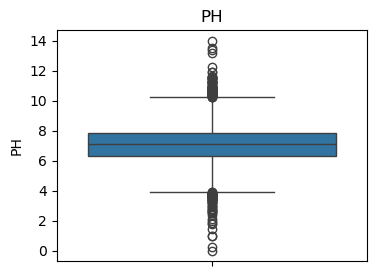

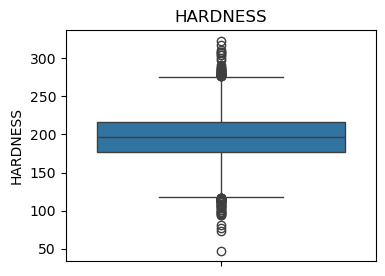

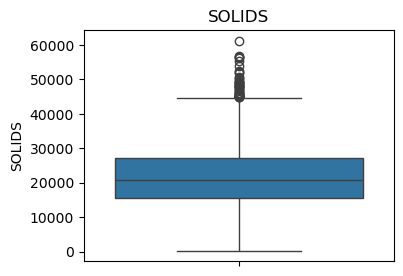

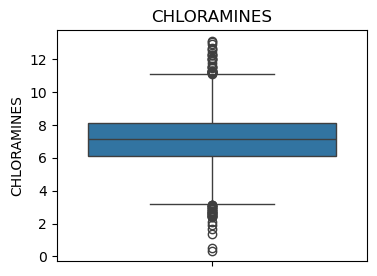

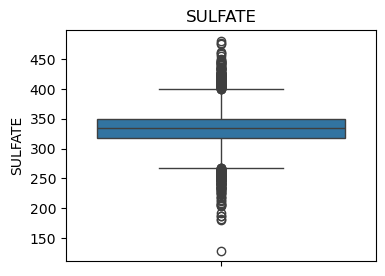

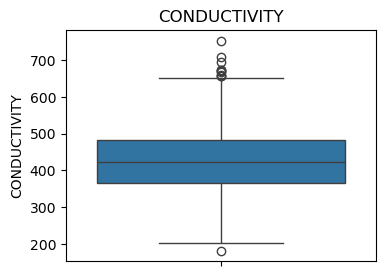

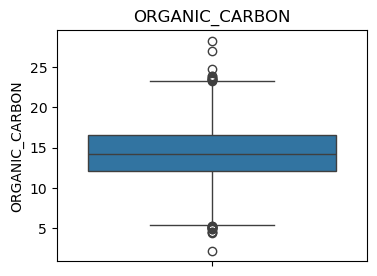

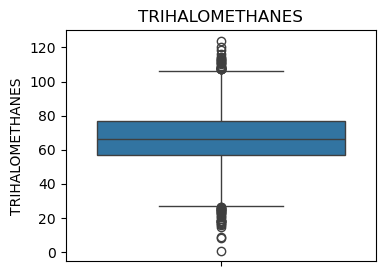

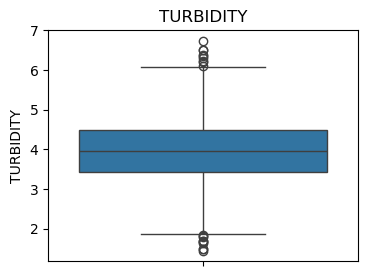

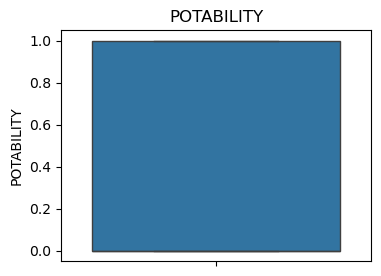

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:

    plt.figure(figsize=(4,3))
    sns.boxplot(y=df[col])

    plt.title(col)
    plt.show()

In [85]:
x=df.drop('POTABILITY',axis=1)

In [86]:
from scipy.stats.mstats import winsorize

for col in x.columns:
    x[col] = winsorize(x[col], limits=[0.05, 0.05])

<BarContainer object of 3276 artists>

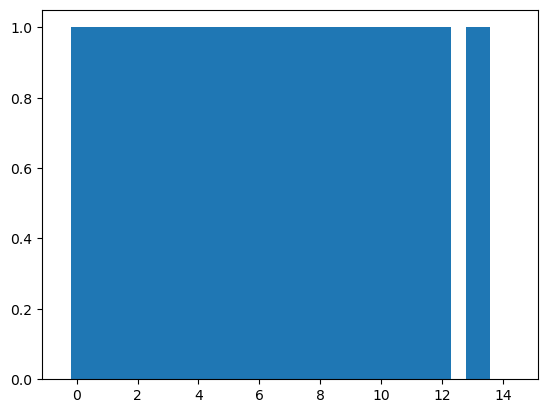

In [87]:
a=df['PH']
b=df['POTABILITY']
plt.bar(a,b)

(array([   4.,   12.,   84.,  353.,  915., 1389.,  382.,  116.,   17.,
           4.]),
 array([ 0. ,  1.4,  2.8,  4.2,  5.6,  7. ,  8.4,  9.8, 11.2, 12.6, 14. ]),
 <BarContainer object of 10 artists>)

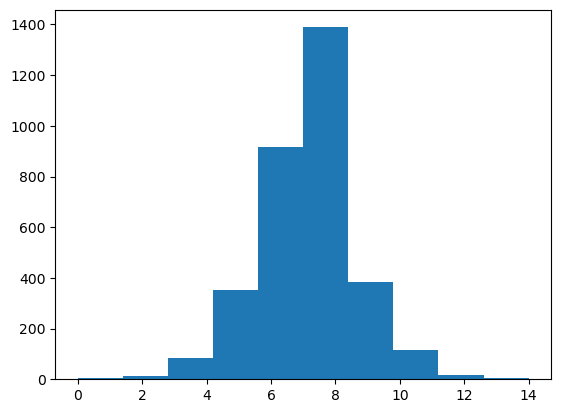

In [88]:
plt.hist(a)

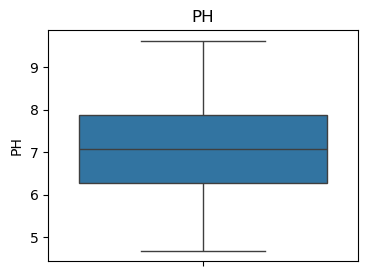

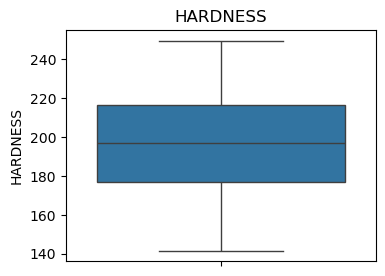

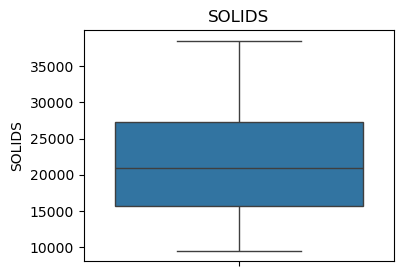

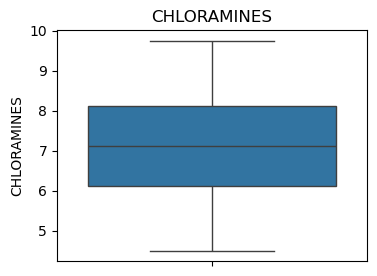

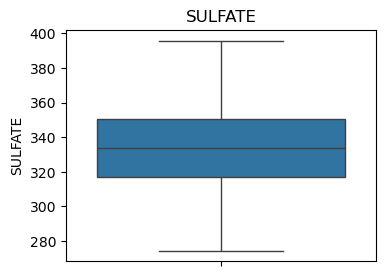

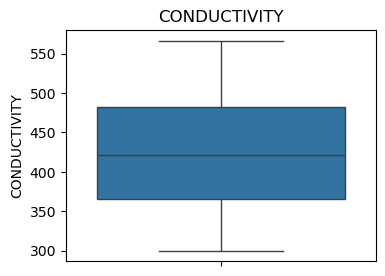

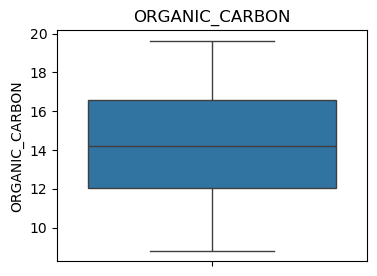

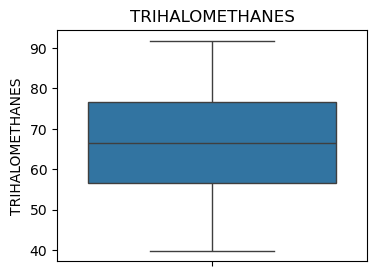

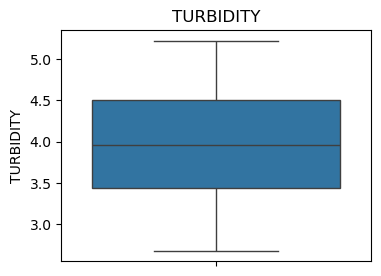

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in x.columns:
    
    plt.figure(figsize=(4,3))
    sns.boxplot(y=x[col])
    
    plt.title(col)
    plt.show()

In [94]:
y=df['POTABILITY']
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
# Pudhu Code (High Accuracy)
x_scaled=sc.fit_transform(x)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=42)
model= SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.6544566544566545
